# DhakaRoadNet: Dataset Download & Verification

This notebook covers the following pipeline steps:
1. **Environment & Path Setup**: Load environment variables and define project root and destination directories.
2. **Download Dataset**: Connect to the Roboflow API using standard credential handlers to fetch version 4 of the traffic dataset.
3. **Dataset Health & Consistency Checks**: Perform verification of image/annotation mapping, checking for alignment issues and background images.
4. **Class Distribution Analysis**: Compute annotation frequencies across all splits (Train, Valid, Test) and visualize them using tables and horizontal bar charts.
5. **Sample Visualizations**: Overlay bounding boxes on random training images to verify labels visually.

### 1. Import Dependencies

In [31]:
from roboflow import Roboflow
from dotenv import load_dotenv, find_dotenv
from pathlib import Path
from collections import Counter
import os
import yaml
import random
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

### 2. Environment Setup & Project Paths

In [32]:
# Load Roboflow API key from .env file
load_dotenv(find_dotenv(usecwd=True))
api_key = os.getenv("ROBOFLOW_API_KEY")

# Define project root and destination path
PROJECT_ROOT = Path(find_dotenv(usecwd=True)).parent
dataset_location = PROJECT_ROOT / "data" / "roboflow"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Dataset Path: {dataset_location}")

Project Root: c:\Users\USER\Desktop\ML\WorkSpace\DhakaRoadNet-EdgeAI
Dataset Path: c:\Users\USER\Desktop\ML\WorkSpace\DhakaRoadNet-EdgeAI\data\roboflow


### 3. Download Dataset from Roboflow

In [33]:
# Check if the dataset is already downloaded to avoid redundant network requests
overwrite = True
if dataset_location.exists() and any(dataset_location.iterdir()):
    overwrite = False
    print("Dataset already downloaded. Skipping download.")
else:
    print("Dataset folder is empty or missing. Starting download...")

# Connect to Roboflow and download the dataset
rf = Roboflow(api_key=api_key)
project = rf.workspace("east-west-university-r3hrx").project("main-road-object-dataset")
version = project.version(4)
dataset = version.download("yolov8", location=str(dataset_location), overwrite=overwrite)

dataset_path = Path(dataset.location)
print(f"\nDataset ready at: {dataset_path}")

Dataset already downloaded. Skipping download.
loading Roboflow workspace...
loading Roboflow project...

Dataset ready at: c:\Users\USER\Desktop\ML\WorkSpace\DhakaRoadNet-EdgeAI\data\roboflow


### 4. Dataset Health & Consistency Checks
We verify if there are any orphaned files (labels without images, or images without labels) and inspect background images (empty label files).

In [34]:
print("--- Dataset Health & Consistency Checks ---")
splits = ["train", "valid", "test"]

for split in splits:
    img_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"
    
    if not img_dir.exists() or not label_dir.exists():
        print(f"\nSplit [{split}]: Image or label directory is missing!")
        continue
        
    img_files = {f.stem: f for f in img_dir.glob("*.*") if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']}
    label_files = {f.stem: f for f in label_dir.glob("*.txt")}
    
    # Check mapping
    images_without_labels = set(img_files.keys()) - set(label_files.keys())
    labels_without_images = set(label_files.keys()) - set(img_files.keys())
    
    empty_label_files = []
    for stem, lbl_path in label_files.items():
        if lbl_path.stat().st_size == 0:
            empty_label_files.append(lbl_path)
            
    print(f"\nSplit: {split.upper()}")
    print(f"  Total Images      : {len(img_files)}")
    print(f"  Total Labels      : {len(label_files)}")
    print(f"  Background Images : {len(images_without_labels)}")
    print(f"  Empty label files : {len(empty_label_files)} (kept as background images ✅)")
    
    # Empty label files name
    if empty_label_files:
        print(f"  Background image list:")
        for lbl_path in empty_label_files:
            print(f"    - {lbl_path.stem}")
    
    if labels_without_images:
        print(f"  [WARNING] Labels without corresponding images: {len(labels_without_images)}")
        for stem in list(labels_without_images)[:5]:
            print(f"    - {stem}.txt")

--- Dataset Health & Consistency Checks ---

Split: TRAIN
  Total Images      : 1754
  Total Labels      : 1754
  Background Images : 0
  Empty label files : 3 (kept as background images ✅)
  Background image list:
    - image_60_jpg.rf.a00033aa7b5546fd4f8895cf0dd2c522
    - image_60_jpg.rf.f4951cdce697eaadddaf9f077f67527a
    - image_60_jpg.rf.f668255f5b5080665866f9d8dc70e255

Split: VALID
  Total Images      : 195
  Total Labels      : 195
  Background Images : 0
  Empty label files : 0 (kept as background images ✅)

Split: TEST
  Total Images      : 196
  Total Labels      : 196
  Background Images : 0
  Empty label files : 0 (kept as background images ✅)


### 5. Analyze & Plot Class Distribution Across Splits


--- Annotation Distribution Summary Table ---


,Class ID,Class Name,Train,Valid,Test,Total
0,6,Human,7480,744,855,9079
1,2,Bus,2535,289,314,3138
2,16,Rickshaw,2300,252,299,2851
3,3,Car,1438,164,173,1775
4,20,Three wheelers -CNG-,1467,141,152,1760
5,12,Motorbike,949,85,122,1156
6,15,Pothole,747,85,111,943
7,18,SUV,334,29,38,401
8,11,Minivan,329,22,39,390
9,23,Zebra Crossing,236,31,27,294



Saved premium class distribution plot to: c:\Users\USER\Desktop\ML\WorkSpace\DhakaRoadNet-EdgeAI\reports\figures\class_distribution.png


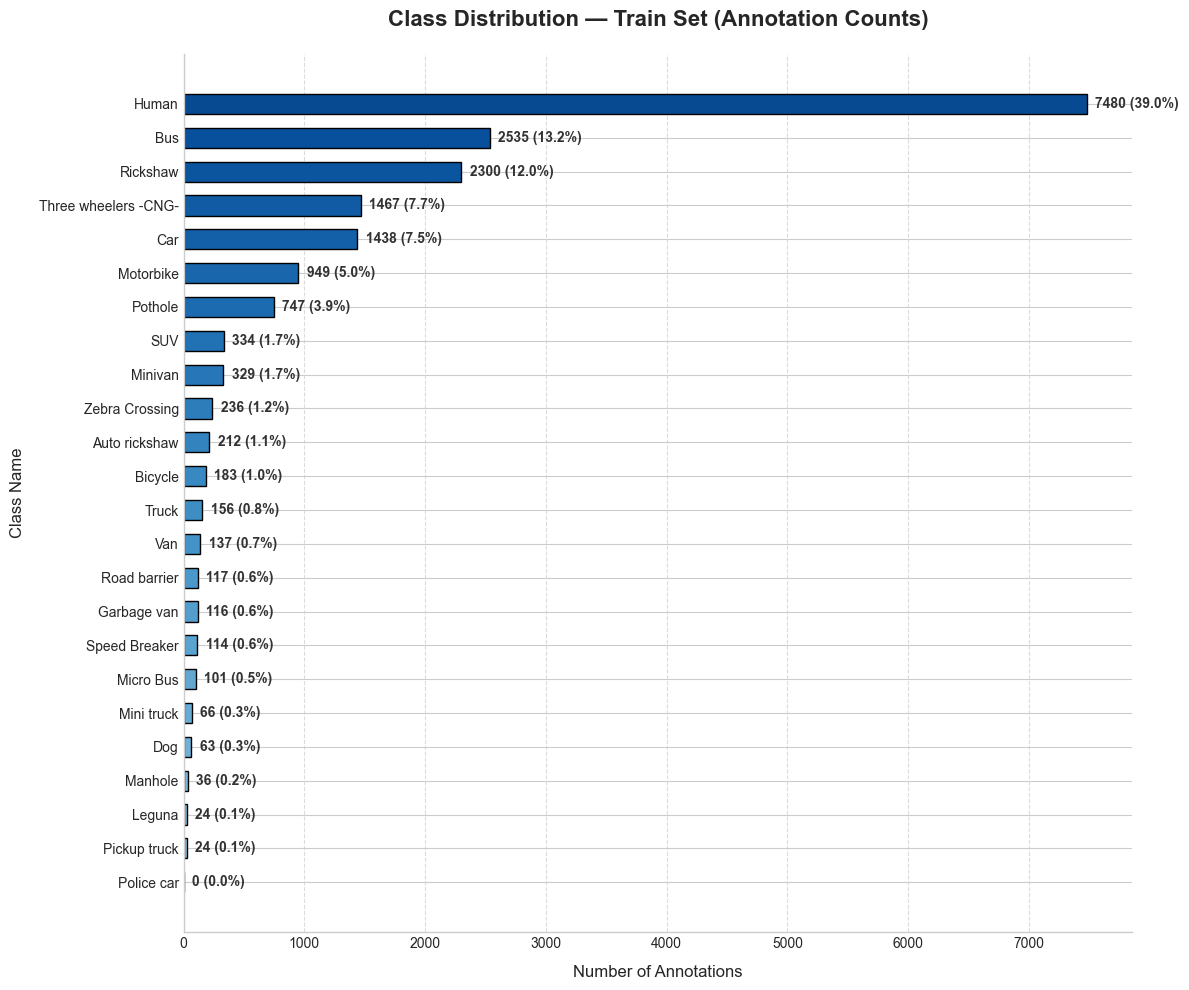

In [35]:
# Load configuration yaml
yaml_path = dataset_path / "data.yaml"
with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)
class_names = data_config["names"]

# Count annotations in each split
split_counts = {}
for split in ["train", "valid", "test"]:
    label_dir = dataset_path / split / "labels"
    counts = Counter()
    if label_dir.exists():
        for label_file in label_dir.glob("*.txt"):
            with open(label_file, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        counts[int(parts[0])] += 1
    split_counts[split] = counts

# Convert to DataFrame for easier analysis
df_data = []
for cid, name in enumerate(class_names):
    df_data.append({
        "Class ID": cid,
        "Class Name": name,
        "Train": split_counts["train"].get(cid, 0),
        "Valid": split_counts["valid"].get(cid, 0),
        "Test": split_counts["test"].get(cid, 0)
    })

df = pd.DataFrame(df_data)
df["Total"] = df["Train"] + df["Valid"] + df["Test"]
df = df.sort_values(by="Total", ascending=False).reset_index(drop=True)

# Display Summary Table
print("\n--- Annotation Distribution Summary Table ---")
display(df)

# Plot Premium Horizontal Bar Chart (Sorted by Frequency)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, ax = plt.subplots(figsize=(12, 10))

# Sort by Train count for plotting
df_plot = df.sort_values(by="Train", ascending=True)

# Generate color gradient from steelblue to darkblue
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_plot)))
bars = ax.barh(df_plot["Class Name"], df_plot["Train"], color=colors, edgecolor="black", height=0.6)

# Add value labels next to bars (Count and Percentage)
total_train_annotations = df_plot["Train"].sum()
for bar in bars:
    width = bar.get_width()
    percentage = (width / total_train_annotations) * 100 if total_train_annotations > 0 else 0
    ax.text(width + (max(df_plot["Train"]) * 0.005), 
            bar.get_y() + bar.get_height()/2, 
            f" {int(width)} ({percentage:.1f}%)", 
            va='center', ha='left', fontsize=10, fontweight='semibold', color="#333333")

# Title and Labels
ax.set_title("Class Distribution — Train Set (Annotation Counts)", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Number of Annotations", fontsize=12, labelpad=10)
ax.set_ylabel("Class Name", fontsize=12, labelpad=10)

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
save_path = PROJECT_ROOT / "reports" / "figures" / "class_distribution.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save_path, dpi=150)
print(f"\nSaved premium class distribution plot to: {save_path}")
plt.show()

### 6. Visualize Random Sample Images with Bounding Boxes
We load a random image from the training split and render its annotated bounding boxes to visually inspect class labeling correctness.

Visualizing Image: image_270_jpg.rf.6ea364c94a4d1a0e1176fae3a15b89b8.jpg
Corresponding Label: image_270_jpg.rf.6ea364c94a4d1a0e1176fae3a15b89b8.txt

Saved sample visualization to: c:\Users\USER\Desktop\ML\WorkSpace\DhakaRoadNet-EdgeAI\reports\figures\sample_visualization.png


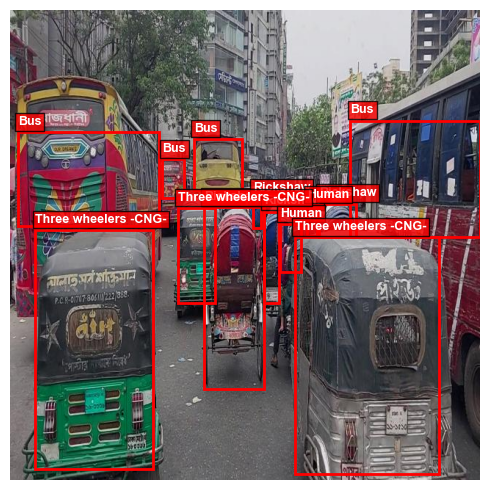

In [37]:
train_img_dir = dataset_path / "train" / "images"
train_label_dir = dataset_path / "train" / "labels"
img_files = list(train_img_dir.glob("*.*"))

if img_files:
    # Pick a random image
    random_img_path = random.choice(img_files)
    corresponding_label_path = train_label_dir / f"{random_img_path.stem}.txt"

    print(f"Visualizing Image: {random_img_path.name}")
    print(f"Corresponding Label: {corresponding_label_path.name}")

    # Read image
    image = cv2.imread(str(random_img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(image)

    # Draw bounding boxes
    if corresponding_label_path.exists():
        with open(corresponding_label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center, y_center, bbox_w, bbox_h = map(float, parts[1:5])
                    
                    # Convert normalized YOLO coordinates to pixel coordinates
                    x1 = int((x_center - bbox_w / 2) * w)
                    y1 = int((y_center - bbox_h / 2) * h)
                    width_px = int(bbox_w * w)
                    height_px = int(bbox_h * h)
                    
                    # Add bounding box rectangle
                    rect = patches.Rectangle(
                        (x1, y1), width_px, height_px,
                        linewidth=2, edgecolor='red', facecolor='none'
                    )
                    ax.add_patch(rect)
                    
                    # Add label text
                    class_name = class_names[class_id]
                    ax.text(
                        x1, y1 - 10, class_name,
                        color='white', bbox=dict(facecolor='red', alpha=0.8, pad=2),
                        fontsize=9, fontweight='bold'
                    )
    else:
        print("No annotation file found for this image.")

    plt.axis('off')
    plt.tight_layout()
    
    # Save sample visualization
    sample_save_path = PROJECT_ROOT / "reports" / "figures" / "sample_visualization.png"
    plt.savefig(sample_save_path, dpi=150)
    print(f"\nSaved sample visualization to: {sample_save_path}")
    plt.show()
else:
    print("No training images found to visualize.")